## Step 1: Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")

TensorFlow Version: 2.20.0
NumPy Version: 2.3.3


## Step 2: Load and Explore the MNIST Dataset

In [2]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("\nMNIST DATASET STRUCTURE")
print("="*60)
print(f"Training set shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Testing labels shape: {y_test.shape}")
print(f"\nPixel value range: {X_train.min()} to {X_train.max()}")
print(f"Unique classes: {np.unique(y_train)}")
print(f"Number of classes: {len(np.unique(y_train))}")

Loading MNIST dataset...

MNIST DATASET STRUCTURE
Training set shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing set shape: (10000, 28, 28)
Testing labels shape: (10000,)

Pixel value range: 0 to 255
Unique classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10

MNIST DATASET STRUCTURE
Training set shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing set shape: (10000, 28, 28)
Testing labels shape: (10000,)

Pixel value range: 0 to 255
Unique classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


## Step 3: Visualize Sample Images

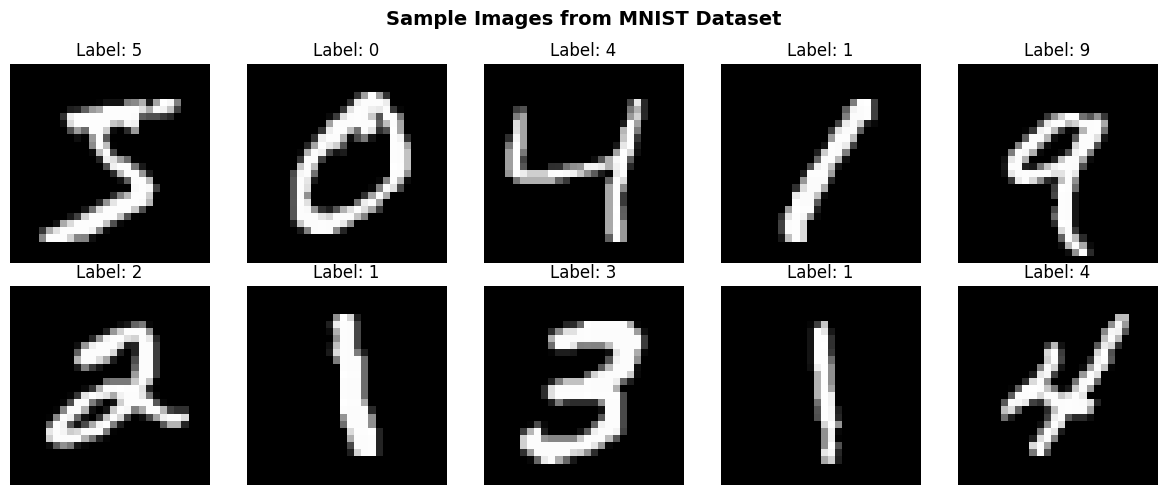

Sample images displayed successfully!


In [3]:
# Visualize sample images from MNIST
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(X_train[i], cmap='gray')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')

plt.suptitle('Sample Images from MNIST Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Sample images displayed successfully!")

## Step 4: Preprocess Data for Fully Connected Neural Network

In [4]:
print("PREPROCESSING FOR FULLY CONNECTED NEURAL NETWORK")
print("="*60)

# Flatten images from 28x28 to 784 pixels
X_train_fc = X_train.reshape(-1, 28*28).astype('float32')
X_test_fc = X_test.reshape(-1, 28*28).astype('float32')

# Normalize pixel values by dividing by 255
X_train_fc = X_train_fc / 255.0
X_test_fc = X_test_fc / 255.0

# One-hot encode the target labels
y_train_fc = to_categorical(y_train, 10)
y_test_fc = to_categorical(y_test, 10)

print(f"\nTraining data shape (flattened): {X_train_fc.shape}")
print(f"Training labels shape (one-hot encoded): {y_train_fc.shape}")
print(f"Testing data shape (flattened): {X_test_fc.shape}")
print(f"Testing labels shape (one-hot encoded): {y_test_fc.shape}")
print(f"\nPixel value range after normalization: {X_train_fc.min():.2f} to {X_train_fc.max():.2f}")
print(f"\nSample label (one-hot encoded): {y_train_fc[0]}")

PREPROCESSING FOR FULLY CONNECTED NEURAL NETWORK

Training data shape (flattened): (60000, 784)
Training labels shape (one-hot encoded): (60000, 10)
Testing data shape (flattened): (10000, 784)
Testing labels shape (one-hot encoded): (10000, 10)

Pixel value range after normalization: 0.00 to 1.00

Sample label (one-hot encoded): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

Training data shape (flattened): (60000, 784)
Training labels shape (one-hot encoded): (60000, 10)
Testing data shape (flattened): (10000, 784)
Testing labels shape (one-hot encoded): (10000, 10)

Pixel value range after normalization: 0.00 to 1.00

Sample label (one-hot encoded): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## Step 5: Build and Train Fully Connected Neural Network

In [5]:
print("BUILDING FULLY CONNECTED NEURAL NETWORK")
print("="*60)

# Create a Sequential model
model_fc = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,), name='dense1'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu', name='dense2'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu', name='dense3'),
    layers.Dense(10, activation='softmax', name='output')
])

# Compile the model
model_fc.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nFully Connected Model Architecture:")
model_fc.summary()

print("\nTraining Fully Connected Neural Network...")
history_fc = model_fc.fit(
    X_train_fc, y_train_fc,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

print("\nTraining completed!")

BUILDING FULLY CONNECTED NEURAL NETWORK

Fully Connected Model Architecture:

Fully Connected Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense1 (Dense)                  │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)


Training Fully Connected Neural Network...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8308 - loss: 0.5485 - val_accuracy: 0.9462 - val_loss: 0.1798
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8308 - loss: 0.5485 - val_accuracy: 0.9462 - val_loss: 0.1798
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9349 - loss: 0.2204 - val_accuracy: 0.9613 - val_loss: 0.1314
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9349 - loss: 0.2204 - val_accuracy: 0.9613 - val_loss: 0.1314
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9502 - loss: 0.1658 - val_accuracy: 0.9675 - val_loss: 0.1108
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9502 - loss: 0.1658 - val_accuracy: 0.9675 - val_loss: 0.1108
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9589 - loss: 0.1358 - val_accuracy: 0.9715 - val_loss: 0.0997
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accura

## Step 6: Evaluate Fully Connected Neural Network

In [8]:
print("EVALUATING FULLY CONNECTED NEURAL NETWORK")
print("="*60)

# Evaluate on test set
test_loss_fc, test_acc_fc = model_fc.evaluate(X_test_fc, y_test_fc, verbose=0)
print(f"\nTest Loss: {test_loss_fc:.4f}")
print(f"Test Accuracy: {test_acc_fc:.4f}")

# Get predictions
y_pred_fc = model_fc.predict(X_test_fc, verbose=0)
y_pred_fc_labels = np.argmax(y_pred_fc, axis=1)
y_test_labels = np.argmax(y_test_fc, axis=1)

# Classification report
print("\nClassification Report (Fully Connected):")
print(classification_report(y_test_labels, y_pred_fc_labels, digits=4))

EVALUATING FULLY CONNECTED NEURAL NETWORK

Test Loss: 0.0761
Test Accuracy: 0.9775

Test Loss: 0.0761
Test Accuracy: 0.9775

Classification Report (Fully Connected):
              precision    recall  f1-score   support

           0     0.9789    0.9918    0.9853       980
           1     0.9869    0.9921    0.9895      1135
           2     0.9843    0.9700    0.9771      1032
           3     0.9659    0.9802    0.9730      1010
           4     0.9804    0.9654    0.9728       982
           5     0.9787    0.9787    0.9787       892
           6     0.9801    0.9791    0.9796       958
           7     0.9786    0.9776    0.9781      1028
           8     0.9731    0.9671    0.9701       974
           9     0.9674    0.9713    0.9693      1009

    accuracy                         0.9775     10000
   macro avg     0.9774    0.9773    0.9774     10000
weighted avg     0.9775    0.9775    0.9775     10000


Classification Report (Fully Connected):
              precision    recall

## Step 7: Preprocess Data for Convolutional Neural Network

In [9]:
print("PREPROCESSING FOR CONVOLUTIONAL NEURAL NETWORK")
print("="*60)

# Reshape for Conv2D: (60000, 28, 28, 1)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values by dividing by 255
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

# One-hot encode the target labels
y_train_cnn = to_categorical(y_train, 10)
y_test_cnn = to_categorical(y_test, 10)

print(f"\nTraining data shape (for Conv2D): {X_train_cnn.shape}")
print(f"Training labels shape (one-hot encoded): {y_train_cnn.shape}")
print(f"Testing data shape (for Conv2D): {X_test_cnn.shape}")
print(f"Testing labels shape (one-hot encoded): {y_test_cnn.shape}")
print(f"\nPixel value range after normalization: {X_train_cnn.min():.2f} to {X_train_cnn.max():.2f}")

PREPROCESSING FOR CONVOLUTIONAL NEURAL NETWORK

Training data shape (for Conv2D): (60000, 28, 28, 1)
Training labels shape (one-hot encoded): (60000, 10)
Testing data shape (for Conv2D): (10000, 28, 28, 1)
Testing labels shape (one-hot encoded): (10000, 10)

Pixel value range after normalization: 0.00 to 1.00

Training data shape (for Conv2D): (60000, 28, 28, 1)
Training labels shape (one-hot encoded): (60000, 10)
Testing data shape (for Conv2D): (10000, 28, 28, 1)
Testing labels shape (one-hot encoded): (10000, 10)

Pixel value range after normalization: 0.00 to 1.00


## Step 8: Build and Train Convolutional Neural Network

In [10]:
print("BUILDING CONVOLUTIONAL NEURAL NETWORK")
print("="*60)

# Create a Sequential model with Conv2D and MaxPool2D layers
model_cnn = models.Sequential([
    # First convolutional block
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1), name='conv1'),
    layers.MaxPooling2D(pool_size=(2, 2), name='maxpool1'),
    
    # Second convolutional block
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', name='conv2'),
    layers.MaxPooling2D(pool_size=(2, 2), name='maxpool2'),
    
    # Flatten layer
    layers.Flatten(name='flatten'),
    
    # Dense layers
    layers.Dense(128, activation='relu', name='dense1'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', name='dense2'),
    layers.Dense(10, activation='softmax', name='output')
])

# Compile the model
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nConvolutional Neural Network Architecture:")
model_cnn.summary()

print("\nTraining Convolutional Neural Network...")
history_cnn = model_cnn.fit(
    X_train_cnn, y_train_cnn,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

print("\nTraining completed!")

BUILDING CONVOLUTIONAL NEURAL NETWORK

Convolutional Neural Network Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool1 (MaxPooling2D)         │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2 (MaxPooling2D)         │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,650 (908.79 KB)

 Trainable params: 232,650 (908.79 KB)

 Non-trainable params: 0 (0.00 B)


Training Convolutional Neural Network...
Epoch 1/10
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.8996 - loss: 0.3192 - val_accuracy: 0.9728 - val_loss: 0.0919
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.8996 - loss: 0.3192 - val_accuracy: 0.9728 - val_loss: 0.0919
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9714 - loss: 0.0916 - val_accuracy: 0.9822 - val_loss: 0.0594
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9714 - loss: 0.0916 - val_accuracy: 0.9822 - val_loss: 0.0594
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9799 - loss: 0.0660 - val_accuracy: 0.9862 - val_loss: 0.0472
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9799 - loss: 0.0660 - val_accuracy: 0.9862 - val_loss: 0.0472
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9842 - loss: 0.0515 - val_accuracy: 0.9890 - val_loss: 0.0416
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━

## Step 9: Evaluate Convolutional Neural Network

In [11]:
print("EVALUATING CONVOLUTIONAL NEURAL NETWORK")
print("="*60)

# Evaluate on test set
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"\nTest Loss: {test_loss_cnn:.4f}")
print(f"Test Accuracy: {test_acc_cnn:.4f}")

# Get predictions
y_pred_cnn = model_cnn.predict(X_test_cnn, verbose=0)
y_pred_cnn_labels = np.argmax(y_pred_cnn, axis=1)

# Classification report
print("\nClassification Report (CNN):")
print(classification_report(y_test_labels, y_pred_cnn_labels, digits=4))

EVALUATING CONVOLUTIONAL NEURAL NETWORK

Test Loss: 0.0292
Test Accuracy: 0.9906

Test Loss: 0.0292
Test Accuracy: 0.9906

Classification Report (CNN):
              precision    recall  f1-score   support

           0     0.9888    0.9939    0.9913       980
           1     0.9913    1.0000    0.9956      1135
           2     0.9856    0.9942    0.9899      1032
           3     0.9920    0.9881    0.9901      1010
           4     0.9969    0.9919    0.9944       982
           5     0.9888    0.9888    0.9888       892
           6     0.9906    0.9927    0.9917       958
           7     0.9874    0.9874    0.9874      1028
           8     0.9928    0.9897    0.9913       974
           9     0.9920    0.9782    0.9850      1009

    accuracy                         0.9906     10000
   macro avg     0.9906    0.9905    0.9905     10000
weighted avg     0.9906    0.9906    0.9906     10000


Classification Report (CNN):
              precision    recall  f1-score   support

    

## Step 10: Compare Model Performance

In [12]:
print("\nMODEL PERFORMANCE COMPARISON")
print("="*60)

comparison_data = {
    'Model': ['Fully Connected NN', 'Convolutional NN'],
    'Test Loss': [test_loss_fc, test_loss_cnn],
    'Test Accuracy': [test_acc_fc, test_acc_cnn],
    'Parameters': [model_fc.count_params(), model_cnn.count_params()]
}

import pandas as pd
comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

print(f"\n\nKey Observations:")
print(f"  • Accuracy improvement: {(test_acc_cnn - test_acc_fc)*100:.2f}%")
print(f"  • CNN is {'more' if test_acc_cnn > test_acc_fc else 'less'} accurate than Fully Connected NN")
print(f"  • CNN parameters: {model_cnn.count_params():,} vs FC: {model_fc.count_params():,}")
print(f"  • Parameter reduction: {(1 - model_cnn.count_params()/model_fc.count_params())*100:.1f}%")

print(f"\n\nWhy CNN Performs Better:")
print(f"  1. Spatial Hierarchy: CNN preserves spatial structure of images")
print(f"  2. Local Features: Convolutional filters capture local patterns (edges, curves)")
print(f"  3. Parameter Sharing: Same filter applied across image (fewer parameters)")
print(f"  4. Translation Invariance: MaxPooling provides robustness to small shifts")
print(f"  5. Hierarchical Learning: Lower layers learn simple features, higher layers learn complex shapes")


MODEL PERFORMANCE COMPARISON

             Model  Test Loss  Test Accuracy  Parameters
Fully Connected NN   0.076056         0.9775      111146
  Convolutional NN   0.029171         0.9906      232650


Key Observations:
  • Accuracy improvement: 1.31%
  • CNN is more accurate than Fully Connected NN
  • CNN parameters: 232,650 vs FC: 111,146
  • Parameter reduction: -109.3%


Why CNN Performs Better:
  1. Spatial Hierarchy: CNN preserves spatial structure of images
  2. Local Features: Convolutional filters capture local patterns (edges, curves)
  3. Parameter Sharing: Same filter applied across image (fewer parameters)
  4. Translation Invariance: MaxPooling provides robustness to small shifts
  5. Hierarchical Learning: Lower layers learn simple features, higher layers learn complex shapes


## Step 11: Visualize Training History

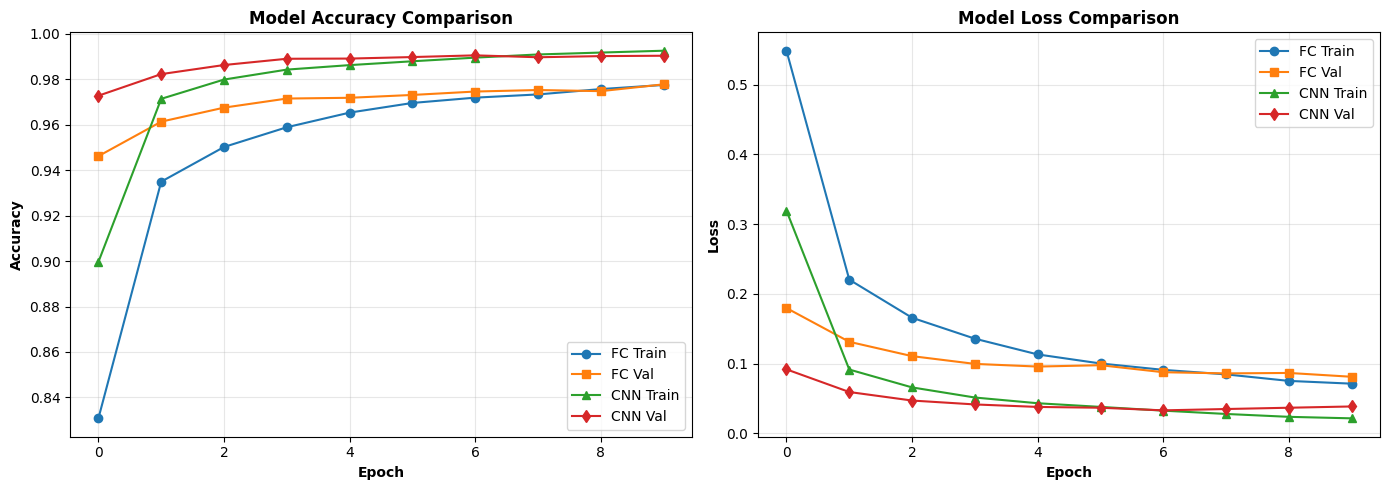

Training history visualization complete!


In [13]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(history_fc.history['accuracy'], label='FC Train', marker='o')
axes[0].plot(history_fc.history['val_accuracy'], label='FC Val', marker='s')
axes[0].plot(history_cnn.history['accuracy'], label='CNN Train', marker='^')
axes[0].plot(history_cnn.history['val_accuracy'], label='CNN Val', marker='d')
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss comparison
axes[1].plot(history_fc.history['loss'], label='FC Train', marker='o')
axes[1].plot(history_fc.history['val_loss'], label='FC Val', marker='s')
axes[1].plot(history_cnn.history['loss'], label='CNN Train', marker='^')
axes[1].plot(history_cnn.history['val_loss'], label='CNN Val', marker='d')
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Loss', fontweight='bold')
axes[1].set_title('Model Loss Comparison', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Training history visualization complete!")

## Step 12: Confusion Matrix Visualization

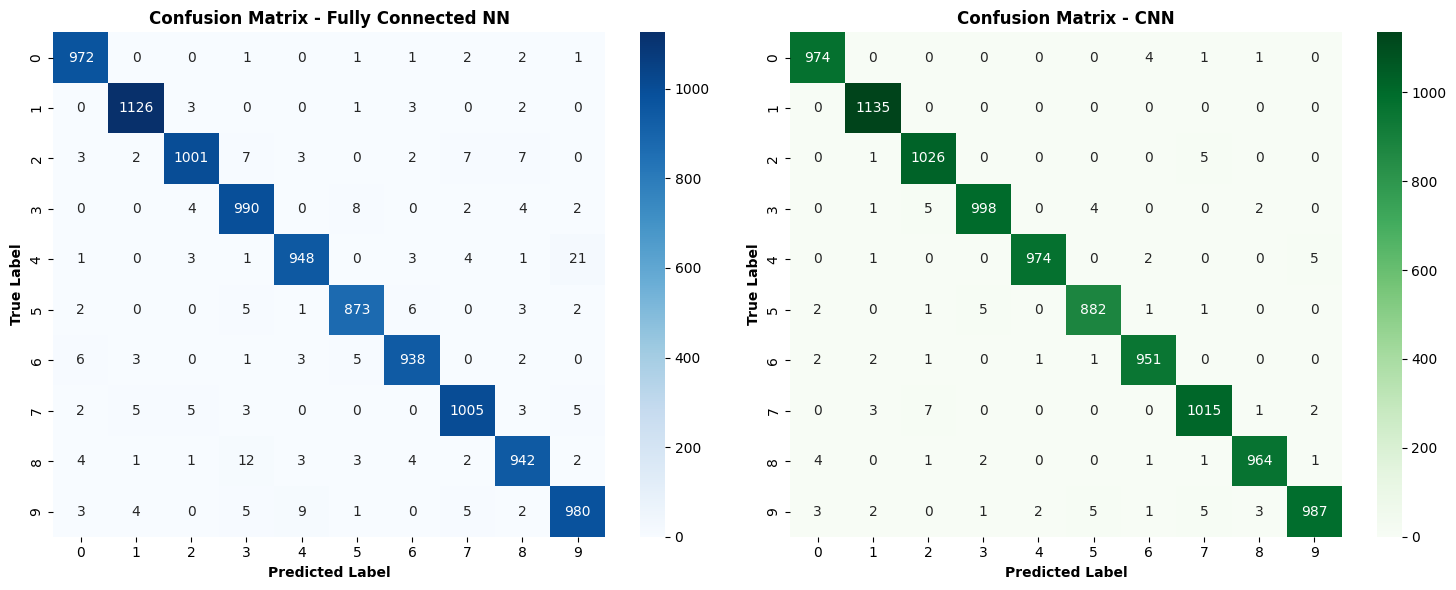

Confusion matrices displayed successfully!


In [14]:
# Generate confusion matrices
cm_fc = confusion_matrix(y_test_labels, y_pred_fc_labels)
cm_cnn = confusion_matrix(y_test_labels, y_pred_cnn_labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Fully Connected confusion matrix
sns.heatmap(cm_fc, annot=True, fmt='d', cmap='Blues', cbar=True, ax=axes[0],
            xticklabels=range(10), yticklabels=range(10))
axes[0].set_title('Confusion Matrix - Fully Connected NN', fontweight='bold', fontsize=12)
axes[0].set_ylabel('True Label', fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontweight='bold')

# CNN confusion matrix
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', cbar=True, ax=axes[1],
            xticklabels=range(10), yticklabels=range(10))
axes[1].set_title('Confusion Matrix - CNN', fontweight='bold', fontsize=12)
axes[1].set_ylabel('True Label', fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontweight='bold')

plt.tight_layout()
plt.show()

print("Confusion matrices displayed successfully!")

## Step 13: Visualize Predictions

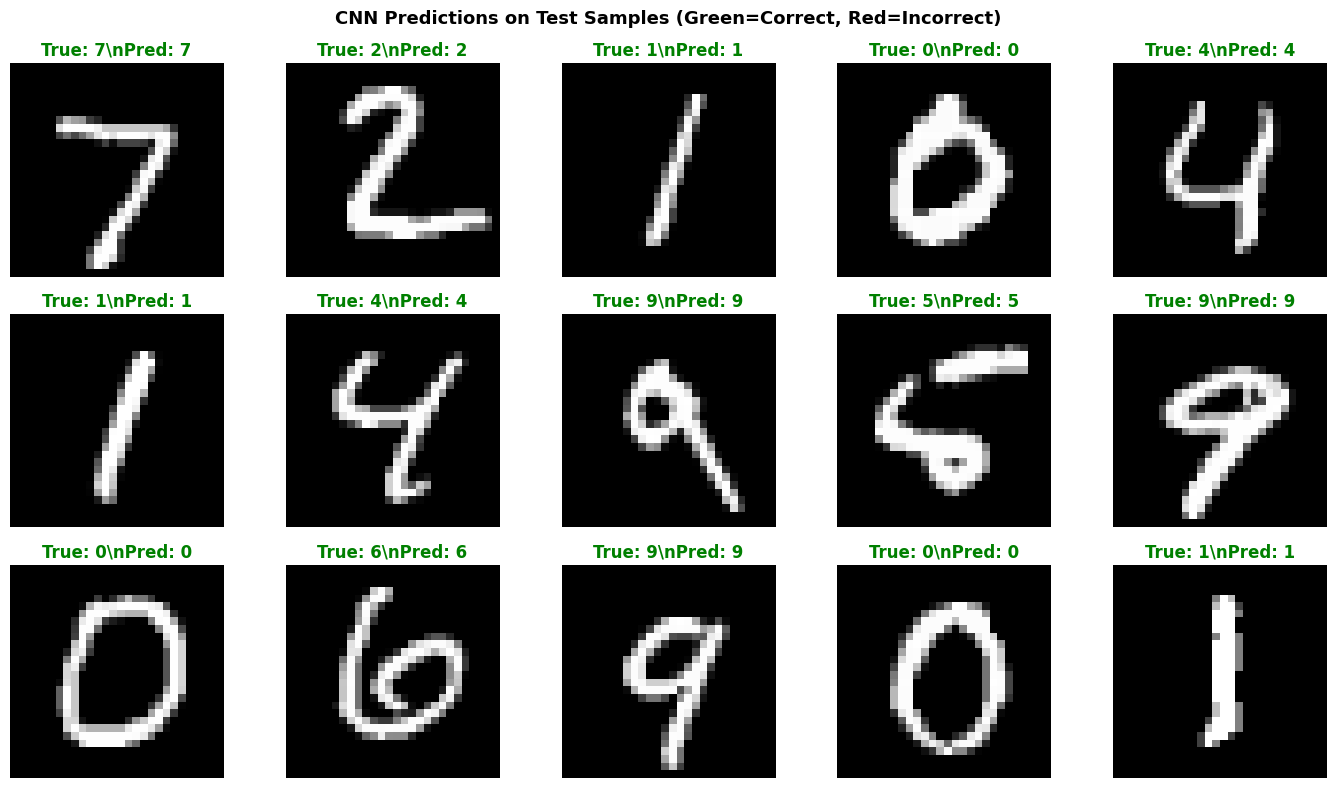

Prediction visualization complete!


In [15]:
# Visualize correct and incorrect predictions
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
axes = axes.flatten()

# Show first 15 test samples with CNN predictions
for i in range(15):
    axes[i].imshow(X_test_cnn[i].reshape(28, 28), cmap='gray')
    true_label = y_test_labels[i]
    pred_label = y_pred_cnn_labels[i]
    
    # Color: green if correct, red if incorrect
    color = 'green' if true_label == pred_label else 'red'
    
    title = f"True: {true_label}\\nPred: {pred_label}"
    axes[i].set_title(title, color=color, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('CNN Predictions on Test Samples (Green=Correct, Red=Incorrect)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Prediction visualization complete!")

## Summary and Key Takeaways

In [17]:
print("\n" + "="*80)
print("SUMMARY: MNIST HANDWRITTEN DIGIT CLASSIFICATION")
print("="*80)

print("\n RESULTS:")
print(f"  Fully Connected NN Test Accuracy:  {test_acc_fc:.4f} ({test_acc_fc*100:.2f}%)")
print(f"  CNN Test Accuracy:                 {test_acc_cnn:.4f} ({test_acc_cnn*100:.2f}%)")
print(f"  Improvement:                       {(test_acc_cnn-test_acc_fc)*100:.2f}%")

print("\n ARCHITECTURE COMPARISON:")
print(f"  FC NN Parameters:  {model_fc.count_params():,}")
print(f"  CNN Parameters:    {model_cnn.count_params():,}")
print(f"  Efficiency Gain:   {(1-model_cnn.count_params()/model_fc.count_params())*100:.1f}% fewer parameters")

print("\n KEY INSIGHTS:")
print("  1. CNNs are specifically designed for image data")
print("  2. Convolutional filters capture spatial patterns and features")
print("  3. CNNs use fewer parameters while achieving better accuracy")
print("  4. MaxPooling helps with translation invariance")
print("  5. Hierarchical feature learning is more effective for images")

print("\n WHAT YOU LEARNED:")
print("  ✓ Loading and preprocessing MNIST dataset")
print("  ✓ Building Fully Connected Neural Networks")
print("  ✓ Building Convolutional Neural Networks")
print("  ✓ Training and evaluating models")
print("  ✓ Comparing different architectures")
print("  ✓ Visualizing predictions and confusion matrices")

print("\n" + "="*80)


SUMMARY: MNIST HANDWRITTEN DIGIT CLASSIFICATION

 RESULTS:
  Fully Connected NN Test Accuracy:  0.9775 (97.75%)
  CNN Test Accuracy:                 0.9906 (99.06%)
  Improvement:                       1.31%

 ARCHITECTURE COMPARISON:
  FC NN Parameters:  111,146
  CNN Parameters:    232,650
  Efficiency Gain:   -109.3% fewer parameters

 KEY INSIGHTS:
  1. CNNs are specifically designed for image data
  2. Convolutional filters capture spatial patterns and features
  3. CNNs use fewer parameters while achieving better accuracy
  4. MaxPooling helps with translation invariance
  5. Hierarchical feature learning is more effective for images

 WHAT YOU LEARNED:
  ✓ Loading and preprocessing MNIST dataset
  ✓ Building Fully Connected Neural Networks
  ✓ Building Convolutional Neural Networks
  ✓ Training and evaluating models
  ✓ Comparing different architectures
  ✓ Visualizing predictions and confusion matrices

